In [1]:
from unsloth import FastVisionModel
import json

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
WARNING 05-12 02:32:48 [interface.py:525] Using 'pin_memory=False' as WSL is detected. This may slow down the performance.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
model, tokenizer = FastVisionModel.from_pretrained("outputs/stage_1/checkpoint-46000/",
                                                   load_in_4bit=False,
                                                   use_gradient_checkpointing="unsloth")

==((====))==  Unsloth 2026.4.6: Fast Qwen3_5 patching. Transformers: 5.5.4. vLLM: 0.19.1.
   \\   /|    NVIDIA RTX A4000. Num GPUs = 1. Max memory: 15.992 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [3]:
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3_5ForConditionalGeneration(
      (model): Qwen3_5Model(
        (visual): Qwen3_5VisionModel(
          (patch_embed): Qwen3_5VisionPatchEmbed(
            (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1024)
          (rotary_pos_emb): Qwen3_5VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-23): 24 x Qwen3_5VisionBlock(
              (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3_5VisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1024, out_features=3072, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_

In [4]:
import sys
import os
from transformers import TextStreamer
import json

In [5]:
from PIL import ImageDraw
import matplotlib.pyplot as plt
import re

In [6]:
from stage_1_datasets_static import build_static_dataset

I0000 00:00:1778524469.900350  398207 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778524469.987047  398207 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778524471.030757  398207 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [8]:
from datasets import load_dataset

In [9]:
# ── 1. Load already-downloaded HF datasets (no re-download) ──────────────────
molmoact   = load_dataset("allenai/MolmoAct-Pretraining-Mixture", "auxiliary_trace")["train"]
pixmocap   = load_dataset("allenai/pixmo-cap")["train"]
pixmoama   = load_dataset("allenai/pixmo-ask-model-anything")["train"]
pixmocapqa = load_dataset("allenai/pixmo-cap-qa")["train"]
# ── 2. Build static dataset (runs once, takes a few minutes for RoboVQA scan) ─
#    ShareRobot, RoboFAC, RoboVQA are loaded automatically from data/ folder.
splits = build_static_dataset(molmoact, pixmocap, pixmoama, pixmocapqa)
# splits is a plain dict:  {"train": VLAStaticDataset, "val": ..., "test": ...}
train_ds = splits["train"]
val_ds   = splits["val"]
print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}")


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/278 [00:00<?, ?it/s]

Building static VLA dataset...
  MolmoAct: 195,622 records
  ShareRobot Affordance: 1,312 records
  ShareRobot Planning: 20,568 records
  RoboVQA: 99,956 records (from 195,818 QA pairs)
  pixmocap: 50,000 records
  pixmoama: 49,750 records
  pixmocapqa: 50,000 records
  RoboFAC: 0 records

Dataset split summary:
  train:  378,929  (81.1%)
  val  :   46,494  (10.0%)
  test :   41,785  (8.9%)
  total:  467,208
Train: 378,929  |  Val: 46,494


In [11]:
tokenizer.video_processor.do_sample_frames = False

In [153]:
data = train_ds[492]

print(f"Dataset: {data['dataset']}")
print(f"Type: {data['type']}")

Dataset: molmoact
Type: trajectory


In [154]:
data = train_ds[494]

print(f"Dataset: {data['dataset']}")
print(f"Type: {data['type']}")

Dataset: robovqa
Type: qa


In [155]:
data['messages'][0]

{'role': 'user',
 'content': [{'type': 'video',
   'video': [<PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>,
    <PIL.Image.Image image mode=RGB size=448x448>]},
  {'type': 'text',
   'text': 'You are a robot manipulation assistant. Answer questions about robot tasks, object affordances

In [157]:
input_text = tokenizer.apply_chat_template(
    [data["messages"][0]],
    add_generation_prompt = True,
    tokenize = False,
    return_dict = True,
    enable_thinking=False,
)
print("-"*20)
print("Input Text:")
print(input_text)
print("Input Text Ended")
print("-"*20)

--------------------
Input Text:
<|im_start|>user
<|vision_start|><|video_pad|><|vision_end|>You are a robot manipulation assistant. Answer questions about robot tasks, object affordances, spatial relationships, and manipulation strategies based on the provided image or video frame.

current goal is: move the chips from the basket to the drawer Q: immediate next step?<|im_end|>
<|im_start|>assistant
<think>

</think>


Input Text Ended
--------------------


In [158]:
inputs = tokenizer.apply_chat_template(
    [data["messages"][0]],
    add_generation_prompt = True,
    tokenize = True,
    return_dict = True,
    return_tensors = "pt",
    enable_thinking=False,
).to(model.device)

In [159]:
if 'video_grid_thw' in inputs:
    print(inputs['video_grid_thw'])
else:
    print(inputs['image_grid_thw'])

tensor([[ 8, 28, 28]], device='cuda:0')


In [160]:
text_streamer = TextStreamer(tokenizer,skip_prompt = True)

In [161]:
outputs = model.generate(
    **inputs,
    streamer = text_streamer,
    max_new_tokens = 4096,
    temperature = 1.5,
    min_p = 0.1,
    use_cache = True,
    eos_token_id=tokenizer.tokenizer.convert_tokens_to_ids("<|im_end|>"),
    repetition_penalty=1.2,   # penalises exact repeats
    stop_strings=["<|im_end|>"],
    tokenizer=tokenizer.tokenizer,
)

put packet in the drawer<|im_end|>


In [162]:
data['messages'][1]

{'role': 'assistant', 'content': 'Put the packet in the drawer'}

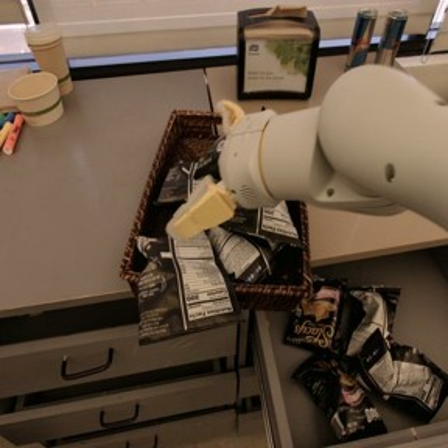

In [163]:
data['image'][0]

USER PROMPT:
You are a robot manipulation assistant. Given an observation image and a task instruction, predict the end-effector's 2D trajectory as 5 waypoints. Output ONLY the coordinate list in this exact format: [[x1,y1],[x2,y2],[x3,y3],[x4,y4],[x5,y5]]

Task: The task is move redbull can near green jalapeno chip bag. What is the trajectory that the end effector should take?

TARGET OUTPUT:
[[662,239],[611,196],[443,168],[443,164],[639,176]]

PREDICTED OUTPUT:
[[705, 254], [600, 250], [529, 235], [509, 235], [490, 227]]


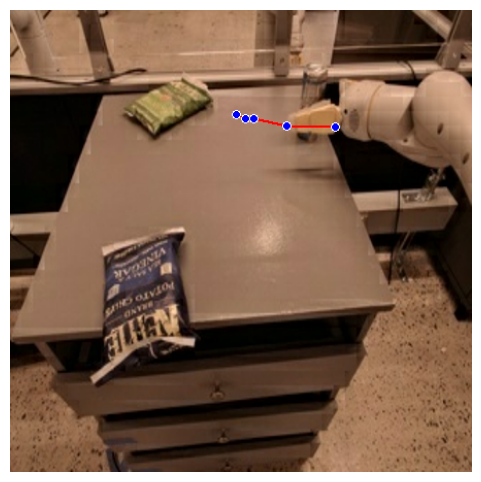

In [148]:
img = data["image"][0]
messages = data["messages"]

# 1. Print the Text Payloads
user_text = messages[0]["content"][1]["text"]
target_output = messages[1]["content"]
qwen_coords = [[705, 254],[600, 250],[529, 235],[509, 235],[490, 227]]

print("USER PROMPT:")
print(user_text)
print("\nTARGET OUTPUT:")
print(target_output)
print("\nPREDICTED OUTPUT:")
print(qwen_coords)

# 2. Visual Verification
# Find all Qwen coordinates looking like (500,200)

qwen_coords = [[705, 254],[600, 250],[529, 235],[509, 235],[490, 227]]
if qwen_coords:
    # We copy the image so we don't permanently draw on the original data
    vis_img = img.copy()
    draw = ImageDraw.Draw(vis_img)
    width, height = vis_img.size
    
    pixel_points = []
    for qx, qy in qwen_coords:
        # Reverse the math: (Qwen_Value / 1000) * Image_Dimension = Pixel
        px = int((int(qx) / 1000.0) * width)
        py = int((int(qy) / 1000.0) * height)
        pixel_points.append((px, py))
    
    # Draw the trajectory path in red
    if len(pixel_points) > 1:
        draw.line(pixel_points, fill="red", width=3)
        
    # Draw the individual waypoints in blue
    for px, py in pixel_points:
        draw.ellipse([px-4, py-4, px+4, py+4], fill="blue", outline="white")
        
    # Render the image using Matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(vis_img)
    plt.axis("off")
    plt.show()

## Saving the full model

In [139]:
model.save_pretrained_merged("stage1_unsloth",
                             tokenizer,
                             save_method="merged_16bit")

Found HuggingFace hub cache directory: /home/ubuntu/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...



Unsloth: Copying 2 files from cache to `stage1_unsloth`:   0%|                                    | 0/2 [00:00<?, ?it/s]
Unsloth: Copying 2 files from cache to `stage1_unsloth`:  50%|██████████████              | 1/2 [00:10<00:10, 10.58s/it]
Unsloth: Copying 2 files from cache to `stage1_unsloth`: 100%|████████████████████████████| 2/2 [00:20<00:00, 10.02s/it]


Successfully copied all 2 files from cache to `stage1_unsloth`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.



Unsloth: Preparing safetensor model files: 100%|████████████████████████████████████████| 2/2 [00:00<00:00, 7523.42it/s]

Unsloth: Merging weights into 16bit: 100%|████████████████████████████████████████████████| 2/2 [00:17<00:00,  8.95s/it]


Unsloth: Merge process complete. Saved to `/home/ubuntu/Shree_FYP/data/stage1_unsloth`


In [150]:
model.push_to_hub_merged("shreethar/stage1_unsloth",
                         tokenizer,
                         save_method="merged_16bit",
                         token = os.environ['hf_token'])

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Found HuggingFace hub cache directory: /home/ubuntu/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...


...


Unsloth: Merging weights into 16bit:  50%|████████████████████████                        | 1/2 [01:25<01:25, 85.42s/it]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Unsloth: Merging weights into 16bit: 100%|████████████████████████████████████████████████| 2/2 [02:57<00:00, 88.95s/it]


Unsloth: Merge process complete. Saved to `/home/ubuntu/Shree_FYP/data/shreethar/stage1_unsloth`
